In [1]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

from config import *

In [2]:
df = pd.read_parquet("../data/stats_dataset.parquet")
df.head()

,fen,next_move,played_by_elo,win_pov,games_count,engine_move,delta,fragility_score,variance,group_count_1000,...,historical_top3_1700,is_historical_top3_1700,group_count_1800,winrate_1800,historical_best_1800,is_historical_best_1800,historical_top2_1800,is_historical_top2_1800,historical_top3_1800,is_historical_top3_1800
0,rnbqkbnr/pppppppp/8/8/3P4/8/PPP1PPPP/RNBQKBNR ...,d7d5,1491,True,145903,g8f6,0.284366,-0.788823,-0.174046,13271.0,...,[d7d5],True,25187.0,0.445944,[d7d5],True,[d7d5],True,[d7d5],True
1,rnbqkbnr/ppp1pppp/8/3p4/3P4/8/PPP1PPPP/RNBQKBN...,c1f4,1433,False,145903,c2c4,-0.612085,-0.807181,-0.156649,13295.0,...,[c1f4],True,25193.0,0.509070,[c1f4],True,[c1f4],True,[c1f4],True
2,rnbqkbnr/ppp1pppp/8/3p4/3P1B2/8/PPP1PPPP/RN1QK...,g8f6,1491,True,33340,e7e6,0.284366,-0.066764,-0.165798,2043.0,...,"[d8d7, h7h5, c8g4]",False,6855.0,0.447702,"[f7f6, h7h5]",False,"[h7h5, f7f6]",False,"[h7h5, f7f6, e7e5]",False
3,rnbqkb1r/ppp1pppp/5n2/3p4/3P1B2/8/PPP1PPPP/RN1...,e2e3,1433,False,30626,e2e3,0.206414,0.116810,-0.163842,1823.0,...,"[f4g3, c2c4, c2c3]",False,6265.0,0.505666,[f2f3],False,"[f2f3, c2c4]",False,"[f2f3, c2c4, f4g3]",False
4,rnbqkb1r/ppp1pppp/5n2/3p4/3P1B2/4P3/PPP2PPP/RN...,c8g4,1491,True,1497,e7e6,-0.027443,2.405371,-0.102601,75.0,...,"[h7h6, c8g4, a7a6]",True,350.0,0.520000,"[a7a6, c8g4, h7h6]",True,"[a7a6, h7h6]",False,"[a7a6, h7h6, c8g4]",True


## Feature Coefficients

In [3]:
coefficients = pd.DataFrame(index=FEATURES)
p_values = pd.DataFrame(index=FEATURES)

for elo in ELOS:
    target = f'is_historical_best_{elo}'
    subset = df.dropna(subset=FEATURES + [target])
    X = sm.add_constant(subset[FEATURES])
    y = subset[target].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, random_state=1, test_size=0.25
    )

    model = sm.Logit(y_train, X_train)
    result = model.fit(disp=0)
    coefficients[f'elo_{elo}'] = result.params
    p_values[f'elo_{elo}'] = result.pvalues

coefficients.to_parquet("../data/coefficients.parquet")
coefficients

,elo_1000,elo_1100,elo_1200,elo_1300,elo_1400,elo_1500,elo_1600,elo_1700,elo_1800
delta,-0.003076,0.067200,-0.023571,0.002178,0.068896,0.044373,-0.000630,0.068311,-0.003323
fragility_score,-0.580015,-0.450515,-0.586048,-0.376751,-0.634348,-0.649730,-0.529459,-0.617759,-0.668972
variance,0.013741,0.062620,0.126706,-0.009941,0.330650,0.140153,0.185358,0.151990,0.117151


In [4]:
# Significance (p-value < 0.05)
p_values < 0.05

,elo_1000,elo_1100,elo_1200,elo_1300,elo_1400,elo_1500,elo_1600,elo_1700,elo_1800
delta,False,True,True,False,True,True,False,True,False
fragility_score,True,True,True,True,True,True,True,True,True
variance,True,True,True,True,True,True,True,True,True


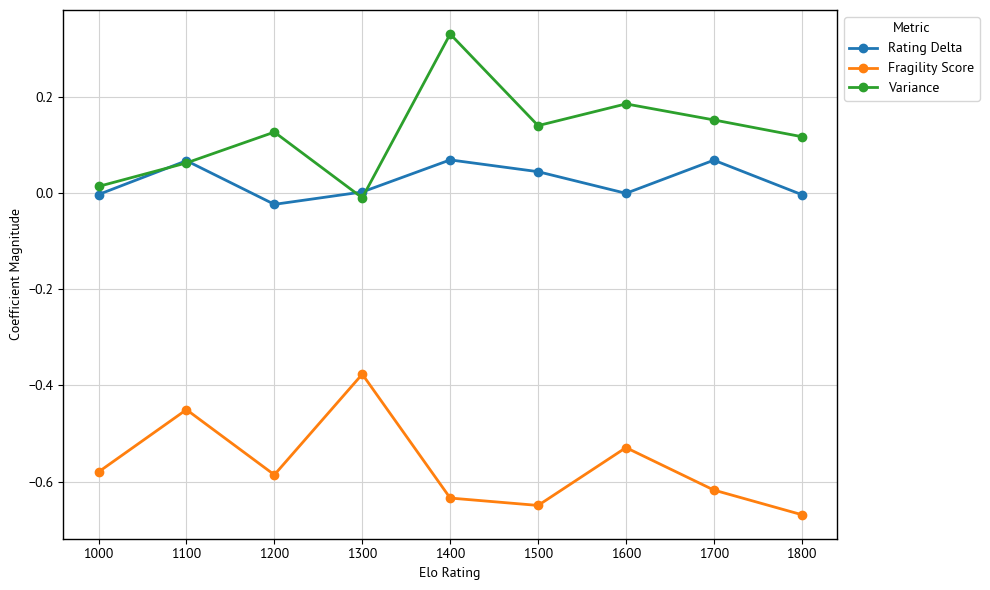

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor("white")

for feature in FEATURES:
    y = coefficients.loc[feature, coefficients.columns].values
    plt.plot(ELOS, y, marker='o', linewidth=2, label=FEATURE_LABELS.get(feature, feature))

ax.set_axisbelow(True)
ax.grid(True, color="lightgray")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)
ax.set_xlabel("Elo Rating")
ax.set_ylabel("Coefficient Magnitude")
plt.xticks(ELOS)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    title="Metric",
    facecolor="white"
)
fig.tight_layout()
fig.savefig("../images/feature_coefficients.pdf")
plt.show()

## Feature Importance

In [6]:
importances = pd.DataFrame(index=FEATURES)

for elo in ELOS:
    target = f'is_historical_best_{elo}'
    subset = df.dropna(subset=FEATURES + [target])
    X = subset[FEATURES]
    y = subset[target].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, random_state=1, test_size=0.25
    )

    model = XGBClassifier(eval_metric='logloss')
    model.fit(X_train, y_train)
    importances[f'elo_{elo}'] = model.feature_importances_

importances.to_parquet("../data/importances.parquet")
importances

,elo_1000,elo_1100,elo_1200,elo_1300,elo_1400,elo_1500,elo_1600,elo_1700,elo_1800
delta,0.157588,0.159504,0.149255,0.148923,0.147087,0.197384,0.134524,0.161028,0.143760
fragility_score,0.571962,0.575488,0.572437,0.576090,0.513036,0.521244,0.556308,0.539498,0.557275
variance,0.270450,0.265007,0.278308,0.274987,0.339876,0.281372,0.309168,0.299474,0.298966


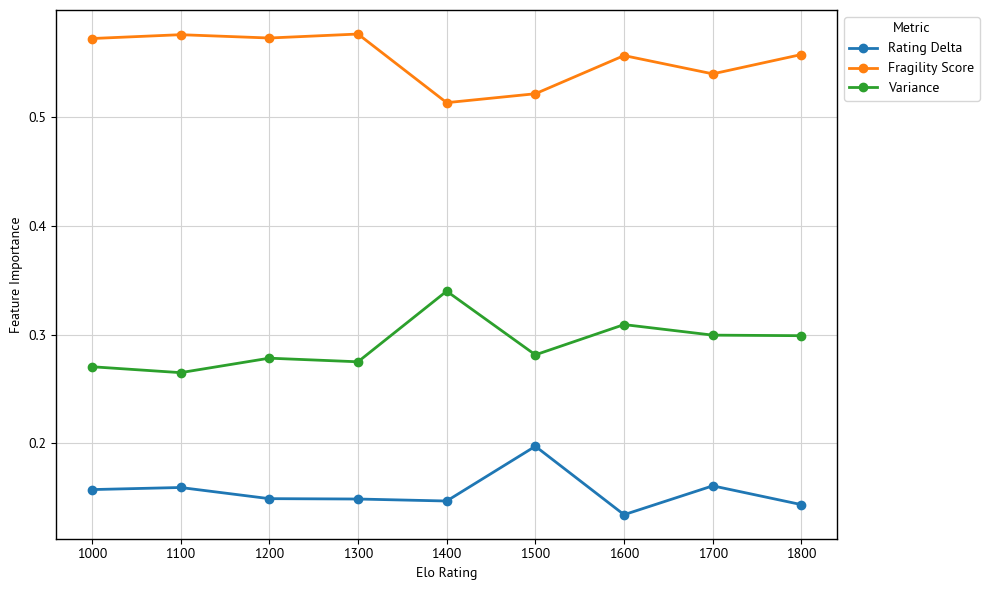

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor("white")

for feature in FEATURES:
    y = importances.loc[feature, importances.columns].values
    ax.plot(ELOS, y, marker='o', linewidth=2, label=FEATURE_LABELS.get(feature, feature))

ax.set_axisbelow(True)
ax.grid(True, color="lightgray")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)
ax.set_xlabel("Elo Rating")
ax.set_ylabel("Feature Importance")
ax.set_xticks(ELOS)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    title="Metric",
    facecolor="white"
)
fig.tight_layout()
fig.savefig("../images/feature_importance.pdf")
plt.show()